## Memory Store Integrating with the LangGraph

### Step 1 : Reading the existing Memory


#### before answering the llm seek the memorystore and personalize the response, just look into the existing memory

In [1]:
# first create the memory store pre built
from langgraph.store.memory import InMemoryStore
store = InMemoryStore()
user_details = ('user','raju','details')
store.put(user_details,'name',{'data':'user name is raju joshi'})
store.put(user_details,'language',{'data':'user likes python over any other language'})
store.put(user_details,'country',{'data':'user is from nepal'})
store.put(user_details,'hobbies',{'data':'user has a hobby of playing cricket video creation and flute playing'})
store.put(user_details,'education',{'data':'user is a graduate cse student'})
store.put(user_details,'working',{'data':'user is an agentic ai engineer at albaconnect'})

In [2]:
# create a prompt
from langchain_core.prompts import PromptTemplate
from langchain_core.messages import SystemMessage

prompt = PromptTemplate(
        template= """You are a helpful assistant with memory capabilities.
                If user-specific memory is available, use it to personalize 
                your responses based on what you know about the user.

                Your goal is to provide relevant, friendly, and tailored 
                assistance that reflects the user’s preferences, context, and past interactions.

                If the user’s name or relevant personal context is available, always personalize your responses by:
                    – Always Address the user by name (e.g., "Sure, Nitish...") when appropriate
                    – Referencing known projects, tools, or preferences (e.g., "your MCP  server python based project")
                    – Adjusting the tone to feel friendly, natural, and directly aimed at the user

                Avoid generic phrasing when personalization is possible. For example, instead of "In TypeScript apps..." 
                say "Since your project is built with TypeScript..."

                Use personalization especially in:
                    – Greetings and transitions
                    – Help or guidance tailored to tools and frameworks the user uses
                    – Follow-up messages that continue from past context

                Always ensure that personalization is based only on known user details and not assumed.

                In the end suggest 3 relevant further questions based on the current response and user profile

                The user’s memory (which may be empty) is provided as: {user_details_content}
            """,
        input_variables=['user_details_content']

)

In [5]:
# build the graph start -> chat-> end
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
load_dotenv()
llm = ChatOpenAI(model = 'gpt-4o-mini')

In [6]:
from langgraph.graph import StateGraph,START,END,MessagesState


In [7]:
from langchain_core.runnables import RunnableConfig
from langgraph.store.memory import BaseStore

In [12]:
def chat_node(state: MessagesState,config : RunnableConfig,store : BaseStore):
    user_id = config['configurable']['thread_id']
    user_details = ('user',user_id,'details')

    items = store.search(user_details)

    if items :
        user_detailed_content = '\n'.join(it.value.get('data','') for it in items)
    else:
        user_detailed_content = ''

    prompt_value = prompt.invoke(input = {
        'user_details_content':user_detailed_content
    })
    system_prompt = SystemMessage(content = prompt_value.to_string())

    response = llm.invoke([system_prompt]+state['messages']) # injecting the ltm into the context window as a part of stm
    return {'messages':[response]}



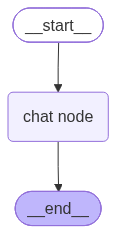

In [13]:
builder = StateGraph(state_schema=MessagesState)
builder.add_node('chat node',chat_node)
builder.add_edge(START,'chat node')
builder.add_edge('chat node',END)
graph = builder.compile(store = InMemoryStore())
graph

In [10]:
from langchain_core.messages import HumanMessage

In [14]:
# now run the graph with config
config1 = {'configurable':{'thread_id':'session-1'}}
result = graph.invoke({
    'messages':[HumanMessage(content= 'explain gen ai in the simpler terms')]
},config=config1)
result

{'messages': [HumanMessage(content='explain gen ai in the simpler terms', additional_kwargs={}, response_metadata={}, id='af295584-59b5-4af7-bc88-78c131079106'),
  AIMessage(content="Sure, Gen AI, or Generative Artificial Intelligence, refers to AI systems that can create new content, such as text, images, music, or even video. Instead of just analyzing or processing existing content, generative AI learns patterns from a large amount of data and then uses this knowledge to generate original pieces of creative work.\n\nFor example, if you give a generative AI model a prompt or some initial information, it can produce a new story, a unique piece of art, or a song that didn't exist before. It’s like having a very intelligent assistant that can create new things based on what it has learned!\n\nIf you're curious about how this type of AI could relate to your work or interests, feel free to ask!\n\nHere are some questions you might consider:\n1. Are you interested in how generative AI can b

In [15]:
print(result['messages'][-1].content)

Sure, Gen AI, or Generative Artificial Intelligence, refers to AI systems that can create new content, such as text, images, music, or even video. Instead of just analyzing or processing existing content, generative AI learns patterns from a large amount of data and then uses this knowledge to generate original pieces of creative work.

For example, if you give a generative AI model a prompt or some initial information, it can produce a new story, a unique piece of art, or a song that didn't exist before. It’s like having a very intelligent assistant that can create new things based on what it has learned!

If you're curious about how this type of AI could relate to your work or interests, feel free to ask!

Here are some questions you might consider:
1. Are you interested in how generative AI can be applied in specific fields, like art or writing?
2. Do you want to know about any popular tools or platforms that use generative AI?
3. Would you like examples of generative AI in action o

## Step 2 : Concept of Creating new memory while chatting

##### till now we know how to interact with the created memory but creating long term memory is the actual big deal here we know how to create the long term memory so firstly we just solo create a long term memory. we learn how to create the long term memory.

In [17]:
# workflow start -> remember ->end and we will store usefull information in the memory store
# pass -> user message into and llm with structured output -> do this is eligible to be a part of long term memroy
# use the pydantic model to get the controlled output

In [23]:
from dotenv import load_dotenv
load_dotenv()

True

In [20]:
from pydantic import BaseModel,Field
class MemoryDecision(BaseModel):
    should_write : bool = Field(descrition= 'is this message can be a part of the long term memory')
    memories : list[str] = Field(description = 'an atomic summary of the user message')

C:\Users\rajen\AppData\Local\Temp\ipykernel_9092\138090758.py:3: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'descrition'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  should_write : bool = Field(descrition= 'is this message can be a part of the long term memory')


In [22]:
from langchain_openai import ChatOpenAI
llm_extractor = ChatOpenAI(model = 'gpt-4o-mini').with_structured_output(schema = MemoryDecision)

In [27]:
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import SystemMessage,AIMessage

In [26]:
import uuid

In [28]:
def remember_only(state: MessagesState,config = RunnableConfig,store = BaseStore):
    user_id = config['configurable']['thread_id']
    user_details = ('user',user_id,'details')

    # take the last message from the state message
    last_message = state['messages'][-1].content

    # llm will decide wheather anything from this is eligible to store in a long term memory
    decision : MemoryDecision = llm_extractor.invoke(
        [SystemMessage(
                content="""
                    "Extract LONG-TERM memories from the user's message.\n"
                    "Only store stable, user-specific info (identity, preferences, ongoing projects).\n"
                    "Do NOT store transient info.\n"
                    "Return should_write=false if nothing is worth storing.\n"
                    "Each memory should be a short atomic sentence."
                    """
                )] 
    +
        [HumanMessage(content= last_message)])

    # writing to long term memory
    if decision.should_write:
        for mem in decision.memories:
            store.put(namespace=user_details,key = str(uuid.uuid4()),value = {'data':mem})


    # IMPORTANT: we are NOT using memory, not even responding with the LLM.
    # We just return a fixed acknowledgement.    

    return {'messages':AIMessage(content= 'Noted')}    

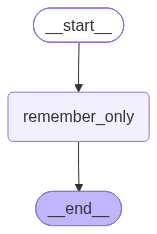

In [29]:
from langgraph.graph import StateGraph,MessagesState,START,END
from langgraph.store.memory import InMemoryStore
builder = StateGraph(state_schema=MessagesState)
builder.add_node('remember_only',remember_only)
builder.add_edge(START,'remember_only')
builder.add_edge('remember_only',END)
store = InMemoryStore()
graph = builder.compile(store = store)
graph

In [ ]:
# ----------------------------
# 4) Demo
# ----------------------------
config1 = {"configurable": {"thread_id": "session-1"}}
res = graph.invoke(input = {
    'messages':[HumanMessage(content='hi my name is raju joshi')]
},config = config1)
print(res['messages'][-1].content)

Noted


In [35]:
res = graph.invoke(input = {
    'messages':[HumanMessage(content='im currently working as an agentic ai engineer')]
},config = config1)
print(res['messages'][-1].content)

Noted


In [36]:
res = graph.invoke(input = {
    'messages':[HumanMessage(content='my favourite programming language is python')]
},config = config1)
print(res['messages'][-1].content)

Noted


In [39]:
items = store.search(('user','session-1','details'))
for  item in items:
    print(item.value['data'])

User's name is Raju Joshi.
User's name is Raju Joshi.
User currently works as an agentic AI engineer.
User's favorite programming language is Python.


### but the main flaw is redundant memory me need a code for deduplicated memory

In [1]:
from dotenv import load_dotenv
load_dotenv()

import uuid
from typing import List
from pydantic import BaseModel, Field

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage
from langchain_core.runnables import RunnableConfig

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [2]:
# ----------------------------
# 1) LTM store
# ----------------------------
store = InMemoryStore()

In [3]:
# ----------------------------
# 2) LLMs
#    - memory_llm: extracts candidate memories + tells if each is NEW (no duplicate_of needed)
# ----------------------------
memory_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [4]:
class MemoryItem(BaseModel):
    text: str = Field(description="Atomic user memory as a short sentence")
    is_new: bool = Field(description="True if this memory is NEW and should be stored. False if duplicate/already known.")

In [5]:
class MemoryDecision(BaseModel):
    should_write: bool = Field(description="Whether to store any memories")
    memories: List[MemoryItem] = Field(default_factory=list, description="Atomic user memories to store")

In [6]:
memory_extractor = memory_llm.with_structured_output(MemoryDecision)

In [8]:
MEMORY_PROMPT = """You are responsible for updating and maintaining accurate user memory.

CURRENT USER DETAILS (existing memories):
{user_details_content}

TASK:
- Review the user's latest message.
- Extract user-specific info worth storing long-term (identity, stable preferences, ongoing projects/goals).
- For each extracted item, set is_new=true ONLY if it adds NEW information compared to CURRENT USER DETAILS.
- If it is basically the same meaning as something already present, set is_new=false.
- Keep each memory as a short atomic sentence.
- No speculation; only facts stated by the user.
- If there is nothing memory-worthy, return an empty list."""

In [9]:
def chat_creates_memory_node(state: MessagesState, config: RunnableConfig, store: BaseStore):

    user_id = config["configurable"]["user_id"]

    namespace = ("user", user_id, "details")

    # A) Load existing memories
    existing_items = store.search(namespace)
    existing_texts = [it.value.get("data", "") for it in existing_items if it.value.get("data")]
    user_details_content = "\n".join(f"- {t}" for t in existing_texts) if existing_texts else "(empty)"

    # B) Latest user message
    last_text = state["messages"][-1]

    # C) LLM extracts memories + marks new vs duplicate
    decision: MemoryDecision = memory_extractor.invoke(
        [
            SystemMessage(content=MEMORY_PROMPT.format(user_details_content=user_details_content)),
            {"role": "user", "content": f"USER MESSAGE:\n{last_text}"},
        ]
    )

    # D) Store ONLY new memories
    if decision.should_write:
        for mem in decision.memories:
            if mem.is_new:
                store.put(namespace, str(uuid.uuid4()), {"data": mem.text})

    return {"messages": [{"role": "assistant", "content": "Noted."}]}

In [10]:
# ----------------------------
# 4) Build graph: START -> chat -> END
# ----------------------------
builder = StateGraph(MessagesState)
builder.add_node("chat", chat_creates_memory_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)

In [11]:
config = {"configurable": {"user_id": "u1"}}

In [12]:
r1 = graph.invoke({"messages": [{"role": "user", "content": "My name is Nitish"}]}, config)
print("Assistant:", r1["messages"][-1].content)

Assistant: Noted.


In [13]:
# Likely duplicate of the first memory -> is_new should be false -> saved=0
r2 = graph.invoke({"messages": [{"role": "user", "content": "I like Python for programming."}]}, config)
print("\nAssistant:", r2["messages"][-1].content)


Assistant: Noted.


In [14]:
for it in store.search(("user", "u1", "details")):
    print(it.value['data'])

The user's name is Nitish.
Nitish likes Python for programming.


In [15]:
r1 = graph.invoke({"messages": [{"role": "user", "content": "My name is Nitish"}]}, config)
print("Assistant:", r1["messages"][-1].content)

Assistant: Noted.


In [16]:
for it in store.search(("user", "u1", "details")):
    print(it.value['data'])

The user's name is Nitish.
Nitish likes Python for programming.


## here the redundant mememory is resolved 